In [45]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [46]:
df = pd.read_csv(r"C:\Coding\AIML\ML Projects\Loan-Approval\Dataset\loan-train.csv")

In [47]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# EDA

In [48]:
df.shape

(614, 13)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [50]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [51]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

<Axes: xlabel='Loan_Status', ylabel='count'>

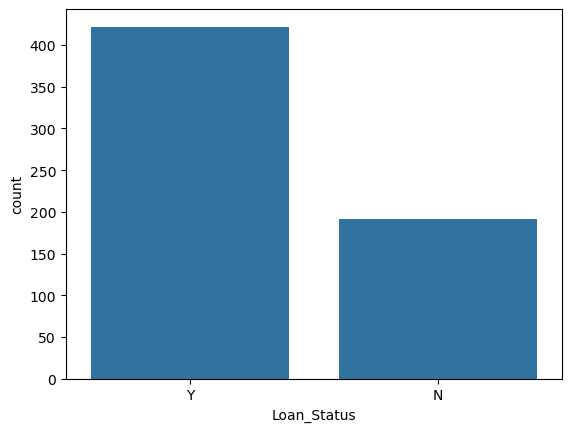

In [52]:
sns.countplot(data=df,x='Loan_Status')

In [53]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

<Axes: xlabel='Credit_History', ylabel='count'>

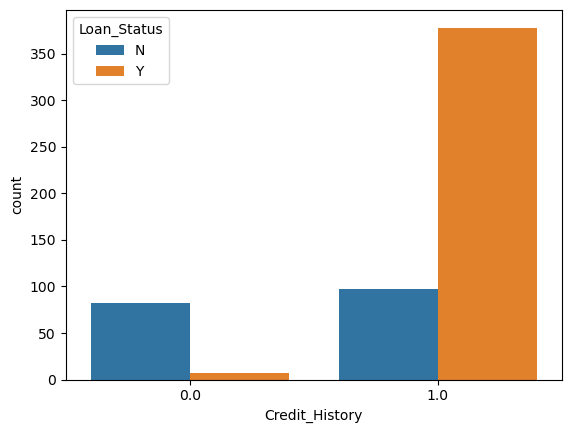

In [54]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

In [55]:
pd.crosstab(df['Credit_History'],df['Loan_Status'])

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,97,378


People with good credit history are highly likely to get loan approval

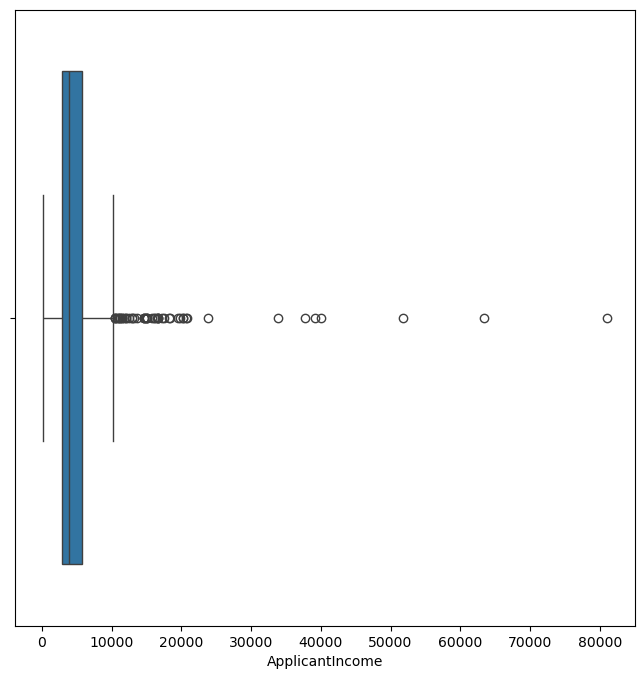

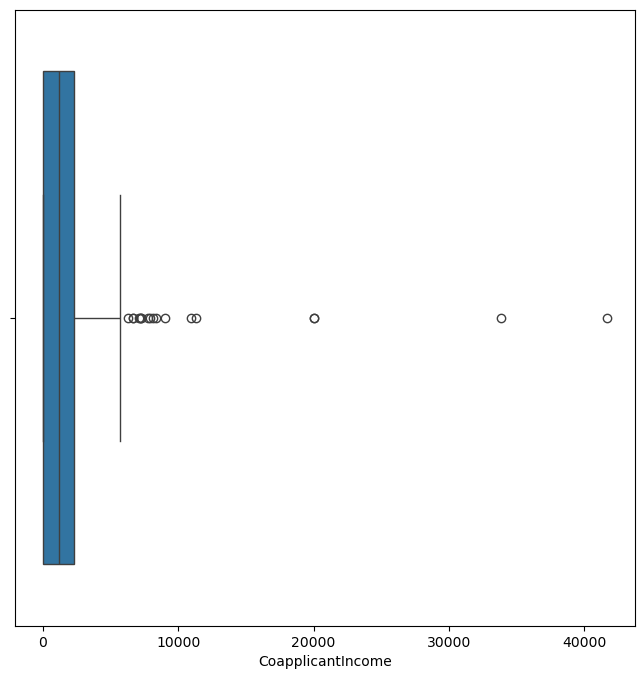

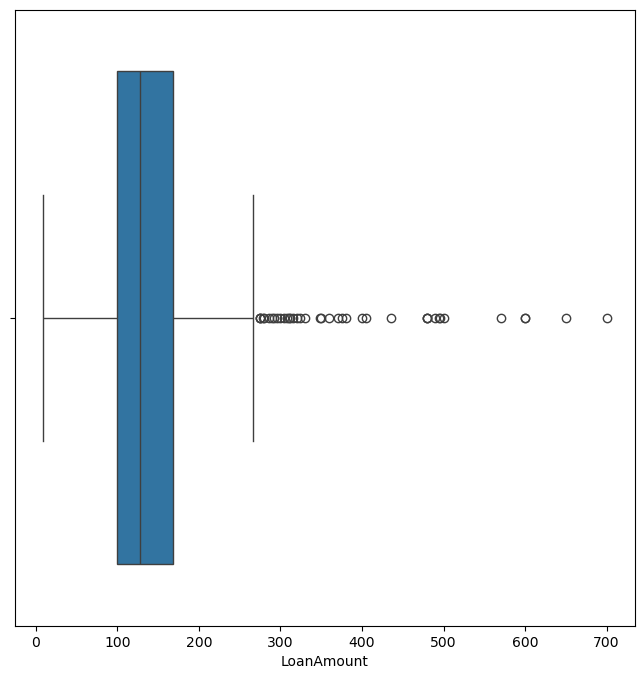

In [56]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount']

for col in num_cols:
    plt.figure(figsize=(8,8))
    sns.boxplot(x=df[col])

# Filling Missing Data

In [57]:
missing_cats = ['Gender','Married','Dependents','Self_Employed']
df_fixed = df.copy()
for col in missing_cats:
    mode = df_fixed[col].mode()[0]
    df_fixed[col]= df_fixed[col].fillna(mode)

In [58]:
missing_nums = ['LoanAmount','Loan_Amount_Term']
for col in missing_nums:
    median = df_fixed[col].median()
    df_fixed[col]=df_fixed[col].fillna(median)

In [59]:
df_fixed['Credit_History'] = df_fixed['Credit_History'].fillna(df_fixed['Credit_History'].mode()[0])

In [60]:
df_fixed.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Preprocessing

In [61]:
df_fixed = df_fixed.drop('Loan_ID',axis=1)

In [62]:
df_fixed["Dependents"] = df_fixed['Dependents'].replace('3+',3)

In [63]:
df_fixed['Dependents'] = df_fixed['Dependents'].astype(int)

In [64]:
print(df_fixed['Dependents'].unique())
df_fixed['Dependents'].dtype

[0 1 2 3]


dtype('int64')

In [65]:
cat_cols = ['Gender','Married','Education','Self_Employed','Loan_Status']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df_fixed[col] = le.fit_transform(df_fixed[col])

In [66]:
df_fixed = pd.get_dummies(data=df_fixed,columns=['Property_Area'],drop_first=True)

In [67]:
df_fixed['Total_Income'] = df_fixed["ApplicantIncome"] + df_fixed['CoapplicantIncome']

In [68]:
df_fixed

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,Total_Income
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,1,False,True,5849.0
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,False,False,6091.0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,False,True,3000.0
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,False,True,4941.0
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,True,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,1,False,False,2900.0
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,1,False,False,4106.0
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,1,False,True,8312.0
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,1,False,True,7583.0


In [69]:
df_fixed.dtypes

Gender                       int64
Married                      int64
Dependents                   int64
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
Property_Area_Semiurban       bool
Property_Area_Urban           bool
Total_Income               float64
dtype: object

In [70]:
df_fixed[['Property_Area_Semiurban','Property_Area_Urban']] = df_fixed[['Property_Area_Semiurban','Property_Area_Urban']].astype(int)

In [71]:
df_fixed

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,Total_Income
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,1,0,1,5849.0
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,0,6091.0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,0,1,3000.0
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,0,1,4941.0
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,0,1,6000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,1,0,0,2900.0
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,1,0,0,4106.0
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,1,0,1,8312.0
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,1,0,1,7583.0


In [72]:
X = df_fixed.drop('Loan_Status',axis=1)
y= df_fixed['Loan_Status']

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [76]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    'Xgboost': XGBClassifier()
}

In [77]:
results = []

In [78]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    results.append({
        "Model":name,
        'Accuracy': round(acc,4),
        'F1-Score': round(f1,4)
    })

In [79]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.7805, 'F1-Score': 0.8457},
 {'Model': 'KNN', 'Accuracy': 0.7967, 'F1-Score': 0.8649},
 {'Model': 'Naive Bayes', 'Accuracy': 0.7886, 'F1-Score': 0.8571},
 {'Model': 'Decision Tree', 'Accuracy': 0.7236, 'F1-Score': 0.7927},
 {'Model': 'SVM', 'Accuracy': 0.7967, 'F1-Score': 0.8649},
 {'Model': 'Random Forest', 'Accuracy': 0.7886, 'F1-Score': 0.8571},
 {'Model': 'AdaBoost', 'Accuracy': 0.7886, 'F1-Score': 0.8587},
 {'Model': 'GradientBoost', 'Accuracy': 0.7805, 'F1-Score': 0.8508},
 {'Model': 'Xgboost', 'Accuracy': 0.748, 'F1-Score': 0.8208}]

In [80]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [81]:
y_pred = grid.predict(X_test)

In [82]:
print(accuracy_score(y_test,y_pred))

0.7886178861788617


No improvement model is at its limits 

# Selecting a model

In [83]:
y_pred_log = models["Logistic Regression"].predict(X_test)
y_pred_knn = models["KNN"].predict(X_test)
y_pred_nb = models["Naive Bayes"].predict(X_test)
y_pred_svm = models["SVM"].predict(X_test)

In [84]:
final_models = []
final_models.extend([y_pred_log,y_pred_knn,y_pred_nb,y_pred_svm])

In [85]:
for m in final_models:
    print(classification_report(y_test,m))
    print()

              precision    recall  f1-score   support

           0       0.79      0.51      0.62        43
           1       0.78      0.93      0.85        80

    accuracy                           0.78       123
   macro avg       0.78      0.72      0.73       123
weighted avg       0.78      0.78      0.77       123


              precision    recall  f1-score   support

           0       1.00      0.42      0.59        43
           1       0.76      1.00      0.86        80

    accuracy                           0.80       123
   macro avg       0.88      0.71      0.73       123
weighted avg       0.85      0.80      0.77       123


              precision    recall  f1-score   support

           0       0.90      0.44      0.59        43
           1       0.76      0.97      0.86        80

    accuracy                           0.79       123
   macro avg       0.83      0.71      0.73       123
weighted avg       0.81      0.79      0.77       123


              pr

# LR have better recall for Class 0 means it have better chances to reject a bad loan , differnce of accuracy is very negligible

Text(50.722222222222214, 0.5, 'Actual')

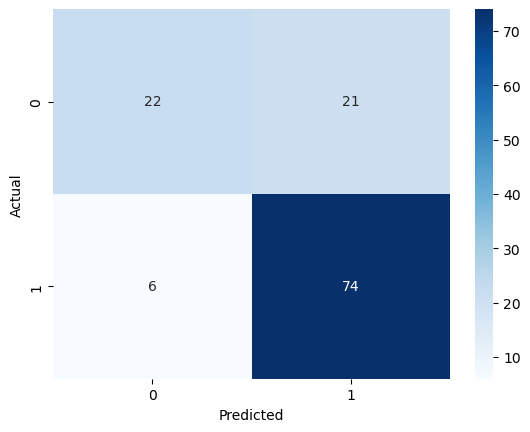

In [86]:
cm = confusion_matrix(y_test,y_pred_log)

sns.heatmap(data=cm,annot=True,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

“The model correctly identifies most approved loans but shows moderate performance in detecting rejected loans, with some false approvals indicating potential risk in real-world use.

In [87]:
import joblib
joblib.dump(models['Logistic Regression'],'Loan_LR.pkl')
joblib.dump(scaler,'Loan_scaler.pkl')
joblib.dump(X.columns.tolist(),'Loan_columns.pkl')

['Loan_columns.pkl']